In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

In [ ]:
class LensingPretrainDataset(Dataset):
    """Dataset for MAE pre-training — only no_sub class, no labels needed"""
    def __init__(self, data_dir):
        self.samples = []
        no_sub_path = os.path.join(data_dir, 'no_sub')
        for fname in os.listdir(no_sub_path):
            if fname.endswith('.npy'):
                self.samples.append(os.path.join(no_sub_path, fname))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = np.load(self.samples[idx], allow_pickle=True)
        if img.dtype == object:
            img = img[0]
        img = img.astype(np.float32)
        # Normalize to [0, 1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = torch.tensor(img).unsqueeze(0)  # (1, 64, 64)
        return img


class LensingClassifyDataset(Dataset):
    """Dataset for fine-tuning — all 3 classes with labels"""
    def __init__(self, data_dir):
        self.samples = []
        self.labels = []
        self.class_map = {'no_sub': 0, 'cdm': 1, 'axion': 2}

        for class_name, label in self.class_map.items():
            class_path = os.path.join(data_dir, class_name)
            for fname in os.listdir(class_path):
                if fname.endswith('.npy'):
                    self.samples.append(os.path.join(class_path, fname))
                    self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = np.load(self.samples[idx], allow_pickle=True)
        if img.dtype == object:
            img = img[0]
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = torch.tensor(img).unsqueeze(0)  # (1, 64, 64)
        return img, self.labels[idx]


# Pre-training dataset (no_sub only)
pretrain_dataset = LensingPretrainDataset('/content/dataset/Dataset')
pretrain_loader = DataLoader(pretrain_dataset, batch_size=64, shuffle=True)

# Classification dataset (all classes, 90:10 split)
full_dataset = LensingClassifyDataset('/content/dataset/Dataset')
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Pre-training samples (no_sub only): {len(pretrain_dataset)}")
print(f"Classification - Train: {train_size}, Test: {test_size}")

Pre-training samples (no_sub only): 29449
Classification - Train: 80193, Test: 8911


In [ ]:
class PatchEmbed(nn.Module):
    """Split image into patches and embed them"""
    def __init__(self, img_size=64, patch_size=8, in_channels=1, embed_dim=256):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2  # 64
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, 1, 64, 64) -> (B, embed_dim, 8, 8) -> (B, 64, embed_dim)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class MAE(nn.Module):
    """Masked Autoencoder with Vision Transformer backbone"""
    def __init__(self, img_size=64, patch_size=8, in_channels=1,
                 encoder_dim=256, encoder_depth=6, encoder_heads=4,
                 decoder_dim=128, decoder_depth=2, decoder_heads=4,
                 mask_ratio=0.75):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.num_patches = (img_size // patch_size) ** 2  # 64

        # Encoder
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, encoder_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, encoder_dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, encoder_dim) * 0.02)
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(encoder_dim, encoder_heads) for _ in range(encoder_depth)
        ])
        self.encoder_norm = nn.LayerNorm(encoder_dim)

        # Decoder
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.randn(1, 1, decoder_dim) * 0.02)
        self.decoder_pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, decoder_dim) * 0.02)
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(decoder_dim, decoder_heads) for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_dim)
        self.decoder_pred = nn.Linear(decoder_dim, patch_size * patch_size * in_channels)

    def random_masking(self, x):
        """Randomly mask patches — keep (1 - mask_ratio) of patches"""
        B, N, D = x.shape  # batch, num_patches, dim
        keep_len = int(N * (1 - self.mask_ratio))

        # Random shuffle and keep first keep_len
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # Keep visible patches
        ids_keep = ids_shuffle[:, :keep_len]
        x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))

        # Binary mask: 0 = keep, 1 = masked
        mask = torch.ones(B, N, device=x.device)
        mask[:, :keep_len] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_visible, mask, ids_restore

    def encode(self, x, mask=True):
        """Encode image — with or without masking"""
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]  # add positional embedding (skip cls position)

        if mask:
            x, mask_out, ids_restore = self.random_masking(x)
        else:
            mask_out = None
            ids_restore = None

        # Add CLS token
        cls = self.cls_token + self.pos_embed[:, :1, :]
        cls = cls.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)

        for block in self.encoder_blocks:
            x = block(x)
        x = self.encoder_norm(x)

        return x, mask_out, ids_restore

    def decode(self, x, ids_restore):
        """Decode — reconstruct all patches from visible ones + mask tokens"""
        x = self.decoder_embed(x)

        # Append mask tokens
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_full = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # skip cls
        x_full = torch.gather(x_full, dim=1,
                              index=ids_restore.unsqueeze(-1).expand(-1, -1, x_full.shape[2]))
        x_full = torch.cat([x[:, :1, :], x_full], dim=1)  # add cls back

        x_full = x_full + self.decoder_pos_embed

        for block in self.decoder_blocks:
            x_full = block(x_full)
        x_full = self.decoder_norm(x_full)

        # Predict pixel values (skip cls token)
        pred = self.decoder_pred(x_full[:, 1:, :])
        return pred

    def patchify(self, imgs):
        """Convert images to patch sequences for loss computation"""
        p = self.patch_size
        h = w = imgs.shape[2] // p
        x = imgs.reshape(imgs.shape[0], 1, h, p, w, p)
        x = x.permute(0, 2, 4, 3, 5, 1).reshape(imgs.shape[0], h * w, p * p)
        return x

    def forward(self, x):
        latent, mask, ids_restore = self.encode(x, mask=True)
        pred = self.decode(latent, ids_restore)
        target = self.patchify(x)

        # MSE loss only on masked patches
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # per-patch loss
        loss = (loss * mask).sum() / mask.sum()  # mean over masked patches only

        return loss, pred, mask

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mae_model = MAE().to(device)
print(f"MAE parameters: {sum(p.numel() for p in mae_model.parameters()):,}")

MAE parameters: 5,219,008


In [ ]:
optimizer = torch.optim.AdamW(mae_model.parameters(), lr=1.5e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

num_epochs = 50

for epoch in range(num_epochs):
    mae_model.train()
    running_loss = 0.0

    pbar = tqdm(pretrain_loader, desc=f"Pre-train Epoch {epoch+1}/{num_epochs}")
    for images in pbar:
        images = images.to(device)

        optimizer.zero_grad()
        loss, _, _ = mae_model(images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    avg_loss = running_loss / len(pretrain_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Avg Loss: {avg_loss:.4f}\n")

# Save pre-trained MAE
torch.save(mae_model.state_dict(), 'mae_pretrained.pth')
print("Pre-trained MAE saved!")

Pre-train Epoch 1/50: 100%|██████████| 461/461 [00:41<00:00, 11.21it/s, loss=0.0055]


Epoch 1/50 - Avg Loss: 0.0098



Pre-train Epoch 2/50: 100%|██████████| 461/461 [00:25<00:00, 18.28it/s, loss=0.0028]


Epoch 2/50 - Avg Loss: 0.0049



Pre-train Epoch 3/50: 100%|██████████| 461/461 [00:20<00:00, 22.11it/s, loss=0.0013]


...

Epoch 48/50 - Avg Loss: 0.0000



Pre-train Epoch 49/50: 100%|██████████| 461/461 [00:20<00:00, 22.26it/s, loss=0.0000]


Epoch 49/50 - Avg Loss: 0.0000



Pre-train Epoch 50/50: 100%|██████████| 461/461 [00:21<00:00, 21.00it/s, loss=0.0000]


Epoch 50/50 - Avg Loss: 0.0000

Pre-trained MAE saved!


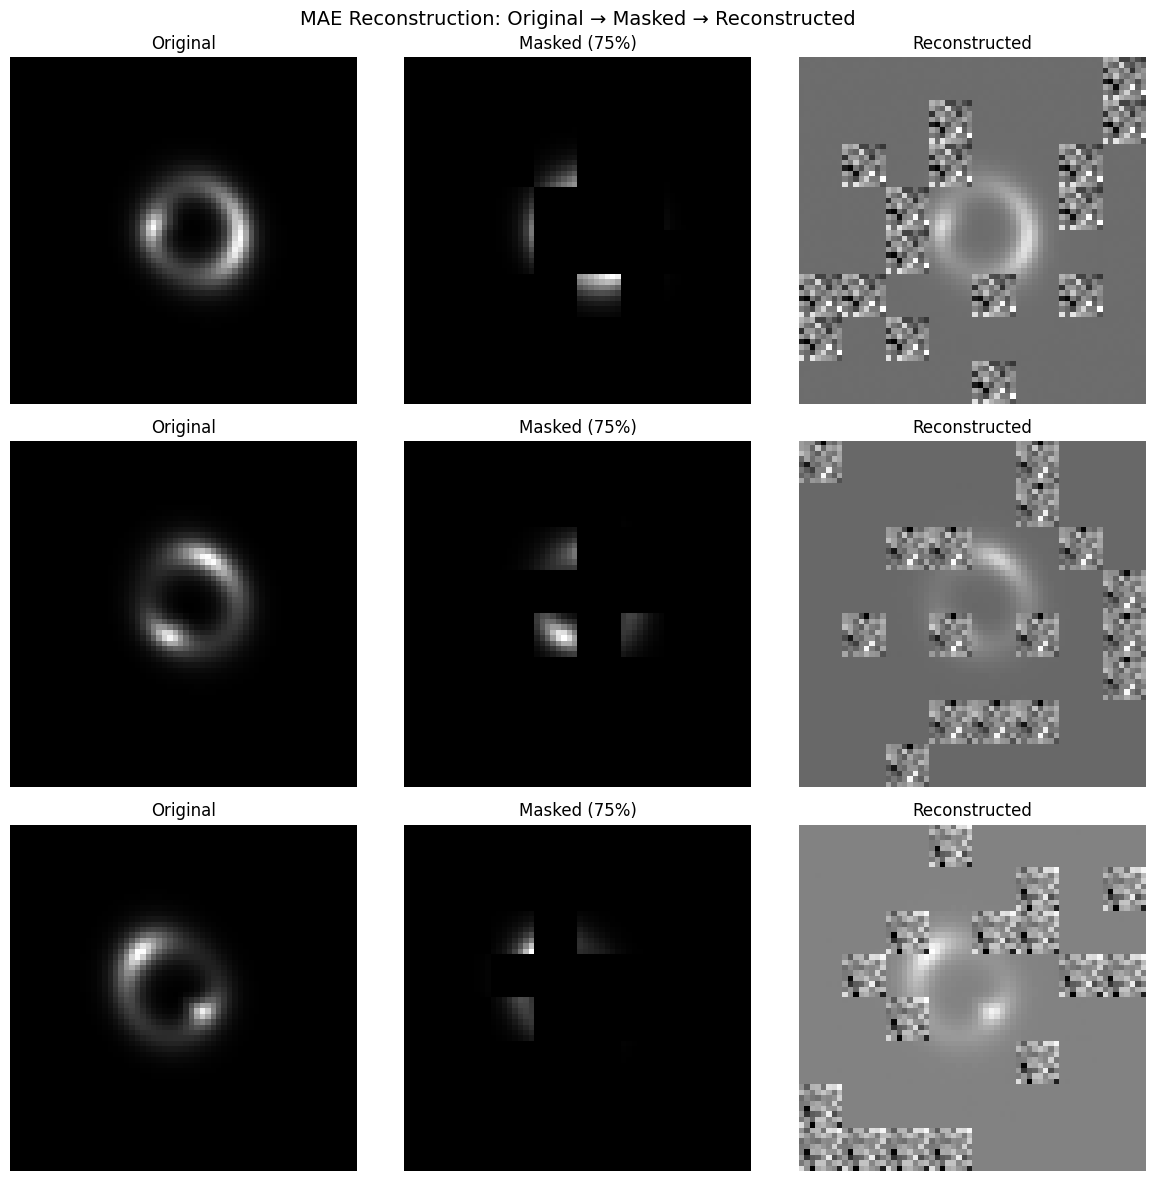

In [ ]:
mae_model.eval()
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

with torch.no_grad():
    sample_imgs = next(iter(pretrain_loader))[:3].to(device)

    for i in range(3):
        img = sample_imgs[i:i+1]
        loss, pred, mask = mae_model(img)

        # Original
        axes[i, 0].imshow(img[0, 0].cpu().numpy(), cmap='gray')
        axes[i, 0].set_title('Original')
        axes[i, 0].axis('off')

        # Masked
        mask_img = img[0, 0].cpu().clone()
        mask_2d = mask[0].reshape(8, 8).repeat_interleave(8, 0).repeat_interleave(8, 1)
        mask_img[mask_2d.bool()] = 0
        axes[i, 1].imshow(mask_img.numpy(), cmap='gray')
        axes[i, 1].set_title('Masked (75%)')
        axes[i, 1].axis('off')

        # Reconstructed
        pred_img = pred[0].reshape(8, 8, 8, 8).permute(0, 2, 1, 3).reshape(64, 64)
        axes[i, 2].imshow(pred_img.cpu().numpy(), cmap='gray')
        axes[i, 2].set_title('Reconstructed')
        axes[i, 2].axis('off')

plt.suptitle('MAE Reconstruction: Original → Masked → Reconstructed', fontsize=14)
plt.tight_layout()
plt.savefig('mae_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
class MAEClassifier(nn.Module):
    """Classification model using pre-trained MAE encoder"""
    def __init__(self, mae_model, num_classes=3):
        super().__init__()
        # Copy encoder components from pre-trained MAE
        self.patch_embed = mae_model.patch_embed
        self.cls_token = mae_model.cls_token
        self.pos_embed = mae_model.pos_embed
        self.encoder_blocks = mae_model.encoder_blocks
        self.encoder_norm = mae_model.encoder_norm

        # New classification head
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Patch embed + positional encoding (no masking)
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]

        # Add CLS token
        cls = self.cls_token + self.pos_embed[:, :1, :]
        cls = cls.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)

        # Encoder
        for block in self.encoder_blocks:
            x = block(x)
        x = self.encoder_norm(x)

        # Classify using CLS token
        cls_output = x[:, 0]
        return self.classifier(cls_output)

classifier = MAEClassifier(mae_model).to(device)
print(f"Classifier parameters: {sum(p.numel() for p in classifier.parameters()):,}")

Classifier parameters: 4,805,891


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

num_epochs = 25

for epoch in range(num_epochs):
    classifier.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Fine-tune Epoch {epoch+1}/{num_epochs}")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = classifier(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.1f}%'
        })

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader):.4f} "
          f"- Acc: {100.*correct/total:.2f}%\n")

Fine-tune Epoch 1/25: 100%|██████████| 1254/1254 [01:59<00:00, 10.51it/s, loss=1.7986, acc=73.8%]


Epoch 1/25 - Loss: 0.5781 - Acc: 73.84%



Fine-tune Epoch 2/25: 100%|██████████| 1254/1254 [01:34<00:00, 13.23it/s, loss=0.0113, acc=84.1%]


Epoch 2/25 - Loss: 0.3959 - Acc: 84.06%



Fine-tune Epoch 3/25: 100%|██████████| 1254/1254 [01:31<00:00, 13.74it/s, loss=1.4415, acc=85.7%]


...

Epoch 23/25 - Loss: 0.1089 - Acc: 94.96%



Fine-tune Epoch 24/25: 100%|██████████| 1254/1254 [01:32<00:00, 13.49it/s, loss=0.0188, acc=95.0%]


Epoch 24/25 - Loss: 0.1079 - Acc: 95.00%



Fine-tune Epoch 25/25: 100%|██████████| 1254/1254 [01:32<00:00, 13.54it/s, loss=0.0003, acc=95.1%]

Epoch 25/25 - Loss: 0.1070 - Acc: 95.07%



Evaluating: 100%|██████████| 140/140 [00:08<00:00, 16.62it/s]


No Substructure: AUC = 0.9997
CDM: AUC = 0.9873
Axion: AUC = 0.9896


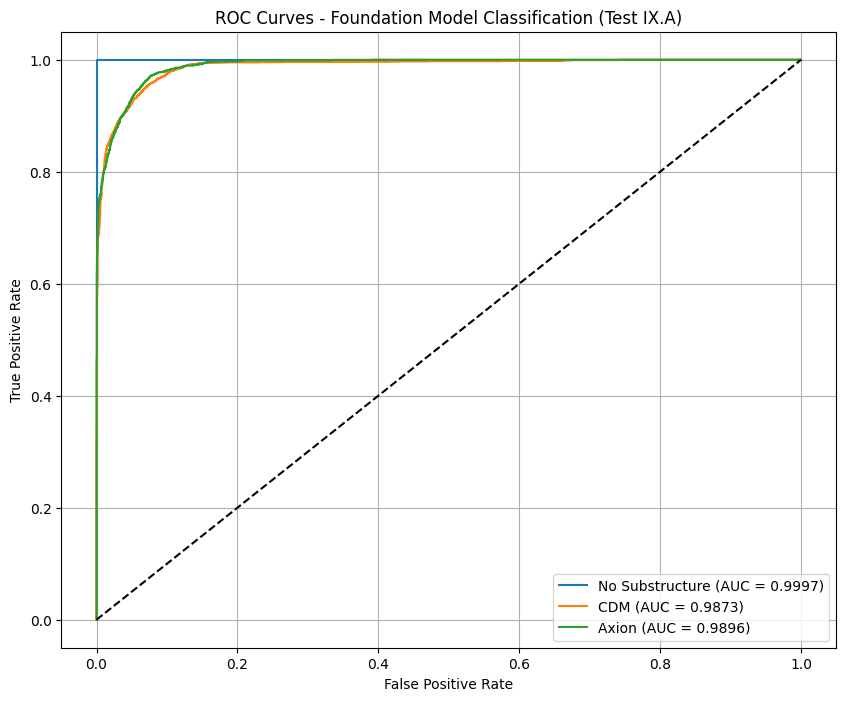


Macro AUC: 0.9922


In [ ]:
classifier.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = classifier(images)
        probs = torch.softmax(outputs, dim=1)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

class_names = ['No Substructure', 'CDM', 'Axion']
plt.figure(figsize=(10, 8))

for i, name in enumerate(class_names):
    binary_labels = (all_labels == i).astype(int)
    fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    print(f"{name}: AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Foundation Model Classification (Test IX.A)')
plt.legend()
plt.grid(True)
plt.savefig('roc_curves_test9a.png', dpi=150, bbox_inches='tight')
plt.show()

macro_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
print(f"\nMacro AUC: {macro_auc:.4f}")

In [ ]:
torch.save(classifier.state_dict(), 'mae_classifier.pth')
print("Classifier saved!")

Classifier saved!
